In [2]:
import pandas as pd, numpy as np
import sys, os
import seaborn as sns
import matplotlib.pyplot as plt
try:
    CURRENT_FOLDER = os.path.dirname(__file__) # normal way
except NameError:
    CURRENT_FOLDER = globals()['_dh'][0] # jupyter notebook way
sys.path.append(os.path.join(CURRENT_FOLDER, "..", "..", "benchmark"))

import benchmark_one

from IPython.display import display

In [8]:
INCREMENTAL_ALGOS = {"CNNR", "CkNNR"}
BEST_STATE_ALGOS = {"EnergyCompress", "CNNR", "CkNNR"}
best_states = dict()

cb_learners = set()
for algo in set(benchmark_one.CB_LEARNERS):
    for classifier in set(benchmark_one.CLASSIFIERS):  
        for dataset in set(benchmark_one.DATASETS):
            try:
                sys.argv = [""] + [dataset] + ["-a", algo] + ["-c", classifier]
                args = benchmark_one.parse_args()
                results = benchmark_one.load_results(args=args)
                df = pd.DataFrame.from_records(results["records"])
                
                run_time = df.sort_values("CB_size", ascending=algo in INCREMENTAL_ALGOS)[["fit_time", "CB_size", "step", "fold"]]#.groupby("fold")["fit_time"].aggregate(list)
                best_states[(args.dataset_name, args.classifier, args.algo,)] = run_time

                cb_learners.add(algo)

            except (FileNotFoundError, ValueError):
                pass

In [18]:
pd.concat(best_states, axis=0, names = ["dataset", "clf", "algo", "fold"])

fit_time  CB_size  \
dataset                              clf     algo fold                      
Ionosphere                           CoAT    cnn  0          NaN       50   
                                                  8          NaN       50   
                                                  18         NaN       50   
                                                  16         NaN       50   
                                                  14         NaN       50   
...                                                          ...      ...   
Kaggle Teaching Assistant Evaluation SVM-rbf ib3  3     0.004721       28   
                                                  17    0.004600       28   
                                                  19    0.004737       28   
                                                  11    0.004164       27   
                                                  9     0.004282       25   

                                                        step  fold  
dataset                              clf     algo fold              
Ionosphere                           CoAT    cnn  0        0     0  
                                                  8        0     4  
                                                  18       0     9  
                                                  16       0     8  
                                                  14       0     7  
...                                                      ...   ...  
Kaggle Teaching Assistant Evaluation SVM-rbf ib3  3        1     1  
                                                  17       1     8  
                                                  19       1     9  
                                                  11       1     5  
                                                  9        1     4  

[100452 rows x 4 columns]

In [70]:
best_states_df = pd.concat(best_states, axis=0, names = ["dataset", "clf", "algo", "fold"])
new_cols = best_states_df.reset_index(level=["dataset", "clf", "algo"])[["dataset", "clf", "algo"]]
new_cols.index = best_states_df.index
best_states_df = pd.concat([best_states_df, new_cols], axis=1)
best_states_df.index = pd.MultiIndex.from_frame(df=best_states_df[["dataset", "clf", "algo", "fold", "step"]])
best_states_df = best_states_df.sort_index()
best_states_df["cum_fit_time"] = best_states_df["fit_time"].groupby(["dataset", "clf", "algo", "fold"]).cumsum()

In [73]:

imprecise_mask = best_states_df["algo"].apply(lambda x: x not in BEST_STATE_ALGOS)
imprecise_runs = best_states_df[imprecise_mask]
#print(best_states_df)
print("involved datasets")
print(imprecise_runs["dataset"].value_counts())
print("involved compression algos")
print(imprecise_runs["algo"].value_counts())
print("involved prediction algos")
print(imprecise_runs["clf"].value_counts())


precise_df = best_states_df[~imprecise_mask]
complete = (precise_df[["dataset", "clf", "algo"]].aggregate(tuple, axis=1).value_counts() == 10)
complete_list = complete.index.to_list()
complete_mask = precise_df[["dataset", "clf", "algo"]].aggregate(tuple, axis=1).apply(lambda x: x in complete_list)
precise_df_complete = precise_df[complete_mask]
precise_df_complete.index = pd.MultiIndex.from_frame(precise_df_complete[["dataset", "clf", "algo", "fold", "step"]])

involved datasets
Balance Scale                           1200
Breast Cancer Wisconsin Diagnostic      1200
Wine                                    1200
Lung Cancer                             1200
Liver Disorders                         1200
Kaggle Teaching Assistant Evaluation    1200
Kaggle Pima Indian Diabetes             1200
Iris                                    1200
Ionosphere                              1200
Hepatitis                               1200
Heart Disease                           1200
Glass Identification                    1200
Dermatology                             1200
Credit Approval                         1200
Zoo                                     1200
Haberman S Survival                     1191
Breast Cancer Wisconsin Prognostic      1191
Lenses                                  1182
Name: dataset, dtype: int64
involved compression algos
cdis     2160
cnn      2160
egdis    2160
ib3      2160
ldis     2160
psdsp    2160
xldis    2160
lssm     2157
icf  

In [74]:
precise_df_complete

fit_time  CB_size  step  fold  \
dataset       clf  algo           fold step                                  
Balance Scale CoAT CNNR           0    0          NaN        1     0     0   
                                       1     0.039523       12     1     0   
                                       2     0.014643       16     2     0   
                                       3     0.013009       20     3     0   
                                       4     0.012237       24     4     0   
...                                               ...      ...   ...   ...   
Zoo           kNN  EnergyCompress 9    45    0.002086        5    45     9   
                                       46    0.001836        4    46     9   
                                       47    0.001980        3    47     9   
                                       48    0.001641        2    48     9   
                                       49    0.001428        1    49     9   

                                                   dataset   clf  \
dataset       clf  algo           fold step                        
Balance Scale CoAT CNNR           0    0     Balance Scale  CoAT   
                                       1     Balance Scale  CoAT   
                                       2     Balance Scale  CoAT   
                                       3     Balance Scale  CoAT   
                                       4     Balance Scale  CoAT   
...                                                    ...   ...   
Zoo           kNN  EnergyCompress 9    45              Zoo   kNN   
                                       46              Zoo   kNN   
                                       47              Zoo   kNN   
                                       48              Zoo   kNN   
                                       49              Zoo   kNN   

                                                       algo  cum_fit_time  
dataset       clf  algo           fold step                                
Balance Scale CoAT CNNR           0    0               CNNR           NaN  
                                       1               CNNR      0.039523  
                                       2               CNNR      0.054166  
                                       3               CNNR      0.067175  
                                       4               CNNR      0.079412  
...                                                     ...           ...  
Zoo           kNN  EnergyCompress 9    45    EnergyCompress      0.251023  
                                       46    EnergyCompress      0.252859  
                                       47    EnergyCompress      0.254839  
                                       48    EnergyCompress      0.256480  
                                       49    EnergyCompress      0.257909  

[78888 rows x 8 columns]

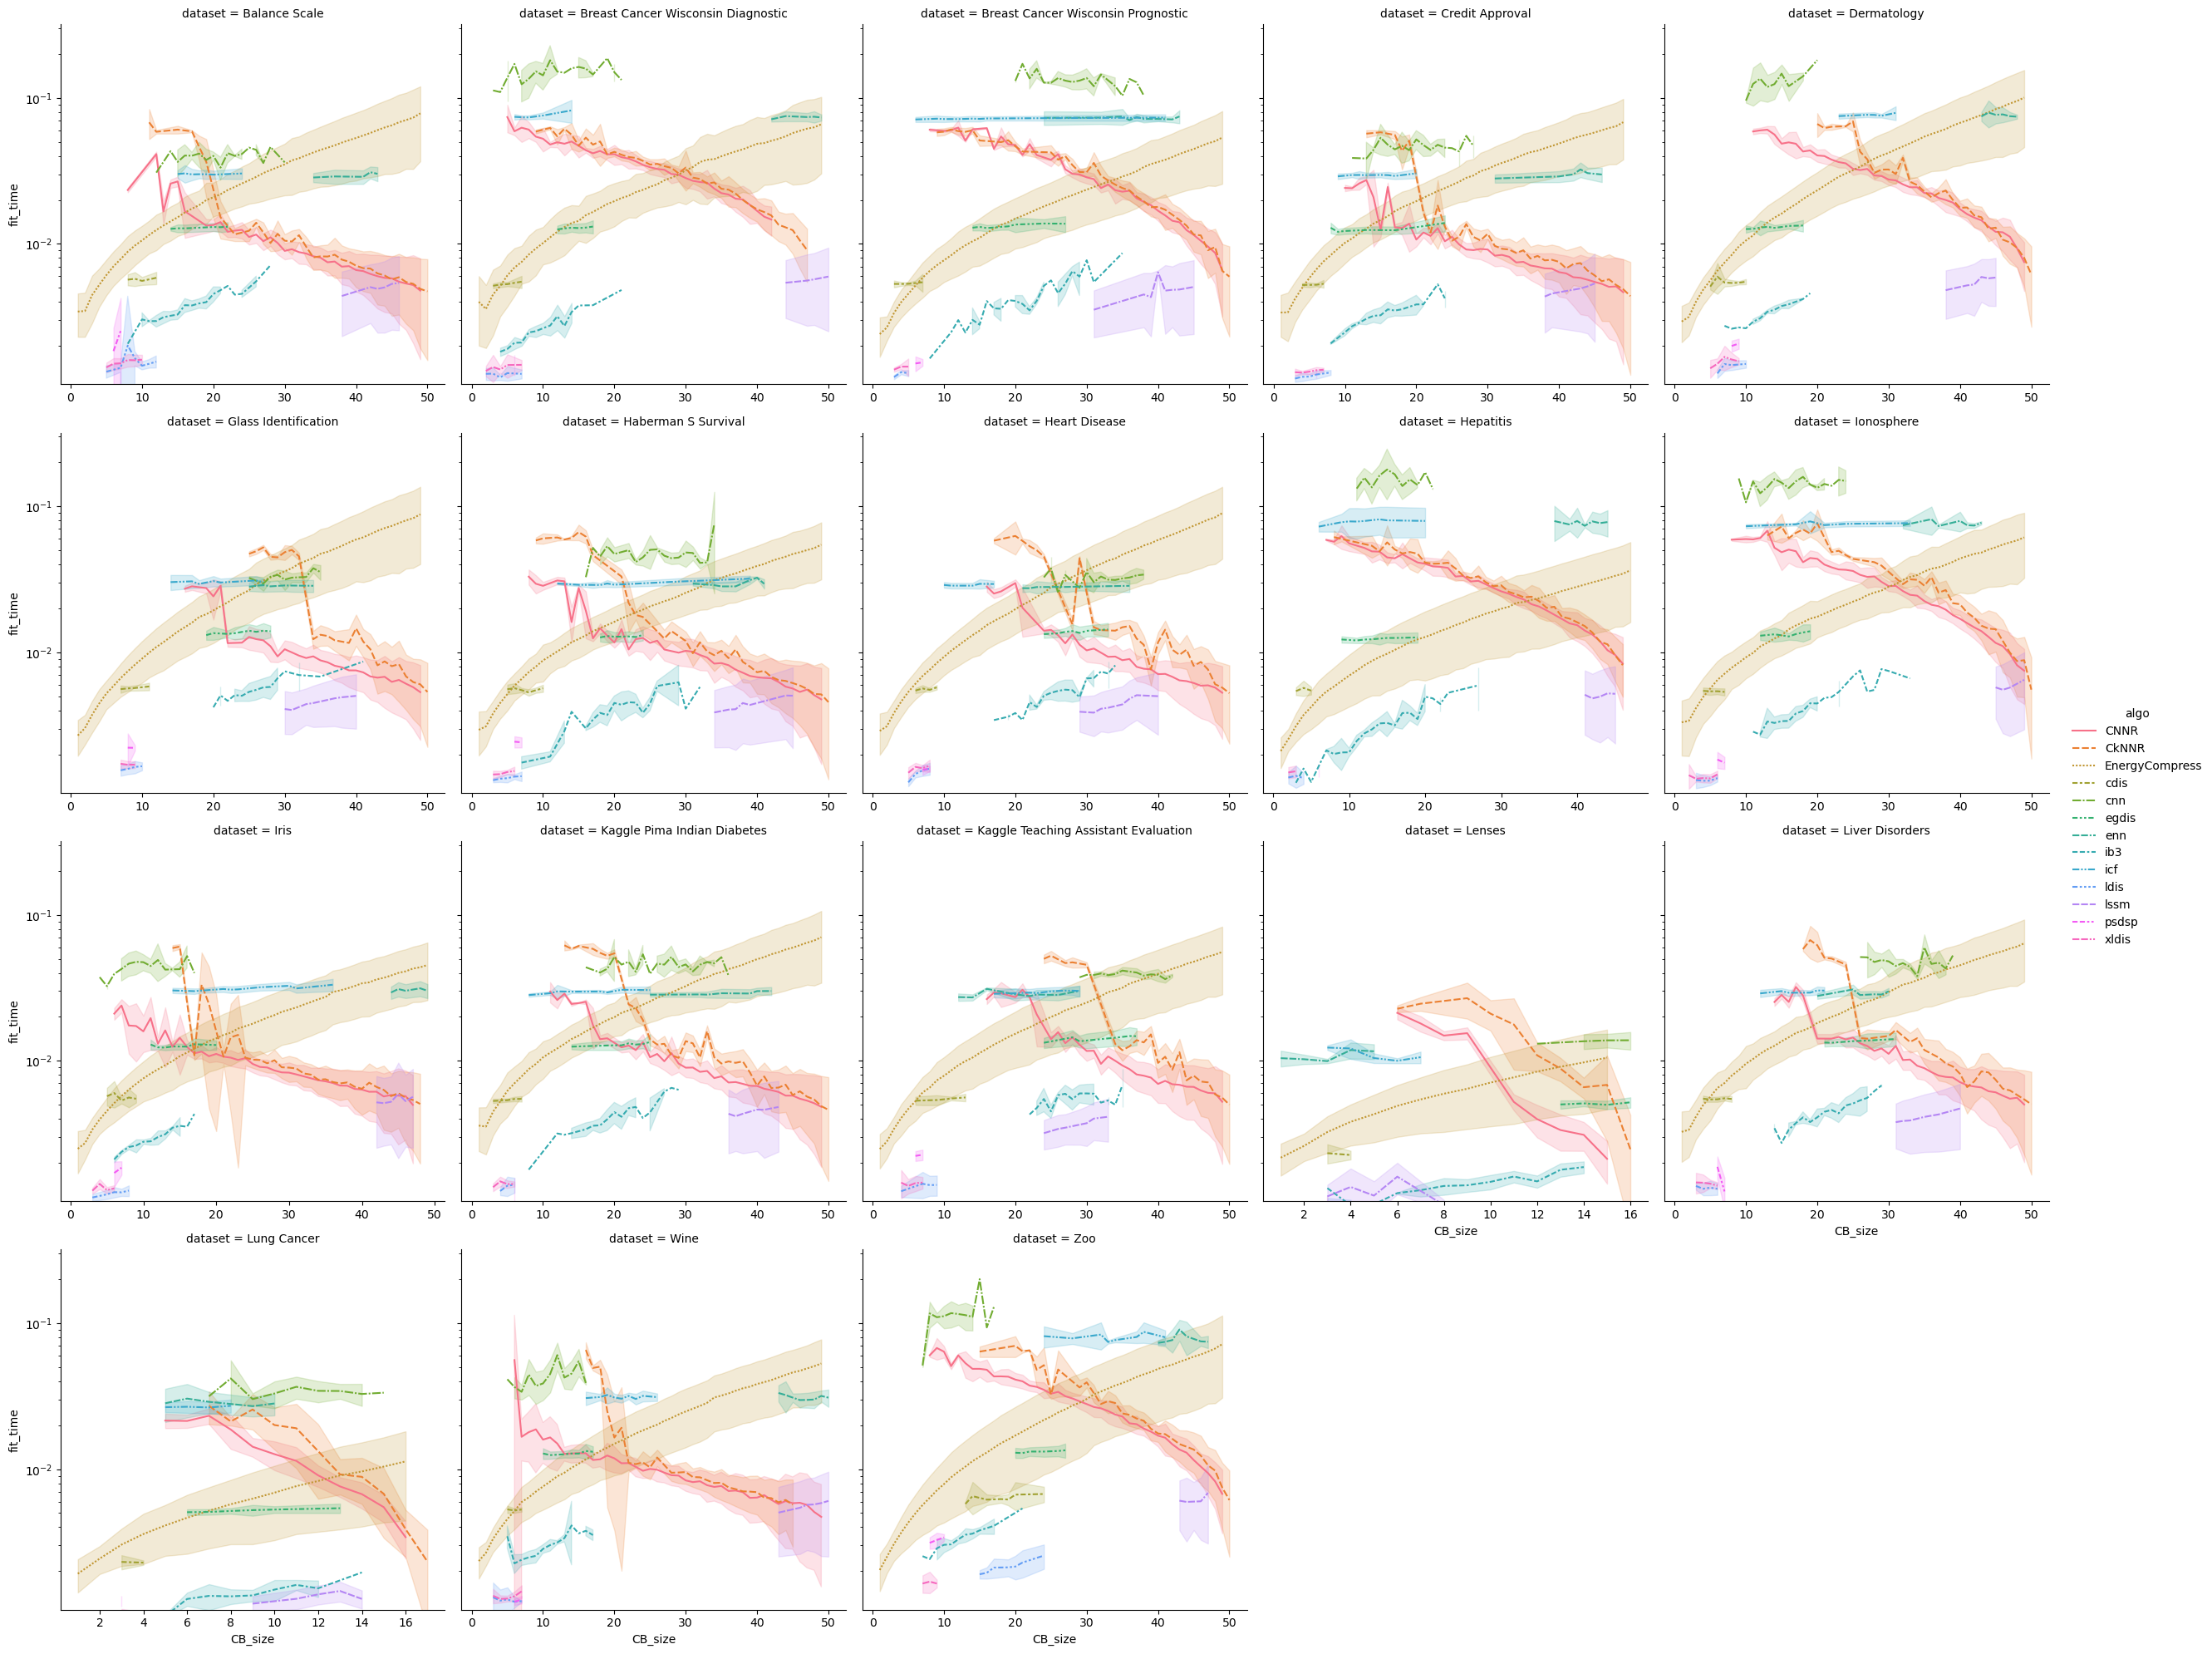

In [75]:
sns.relplot(
    best_states_df.reset_index(drop="fold"),
    x="CB_size",
    y="fit_time",
    hue="algo", style="algo", 
    col="dataset", col_wrap = 5,
    kind="line", errorbar=('sd'), facet_kws={"sharex":False}).set(yscale = 'log')

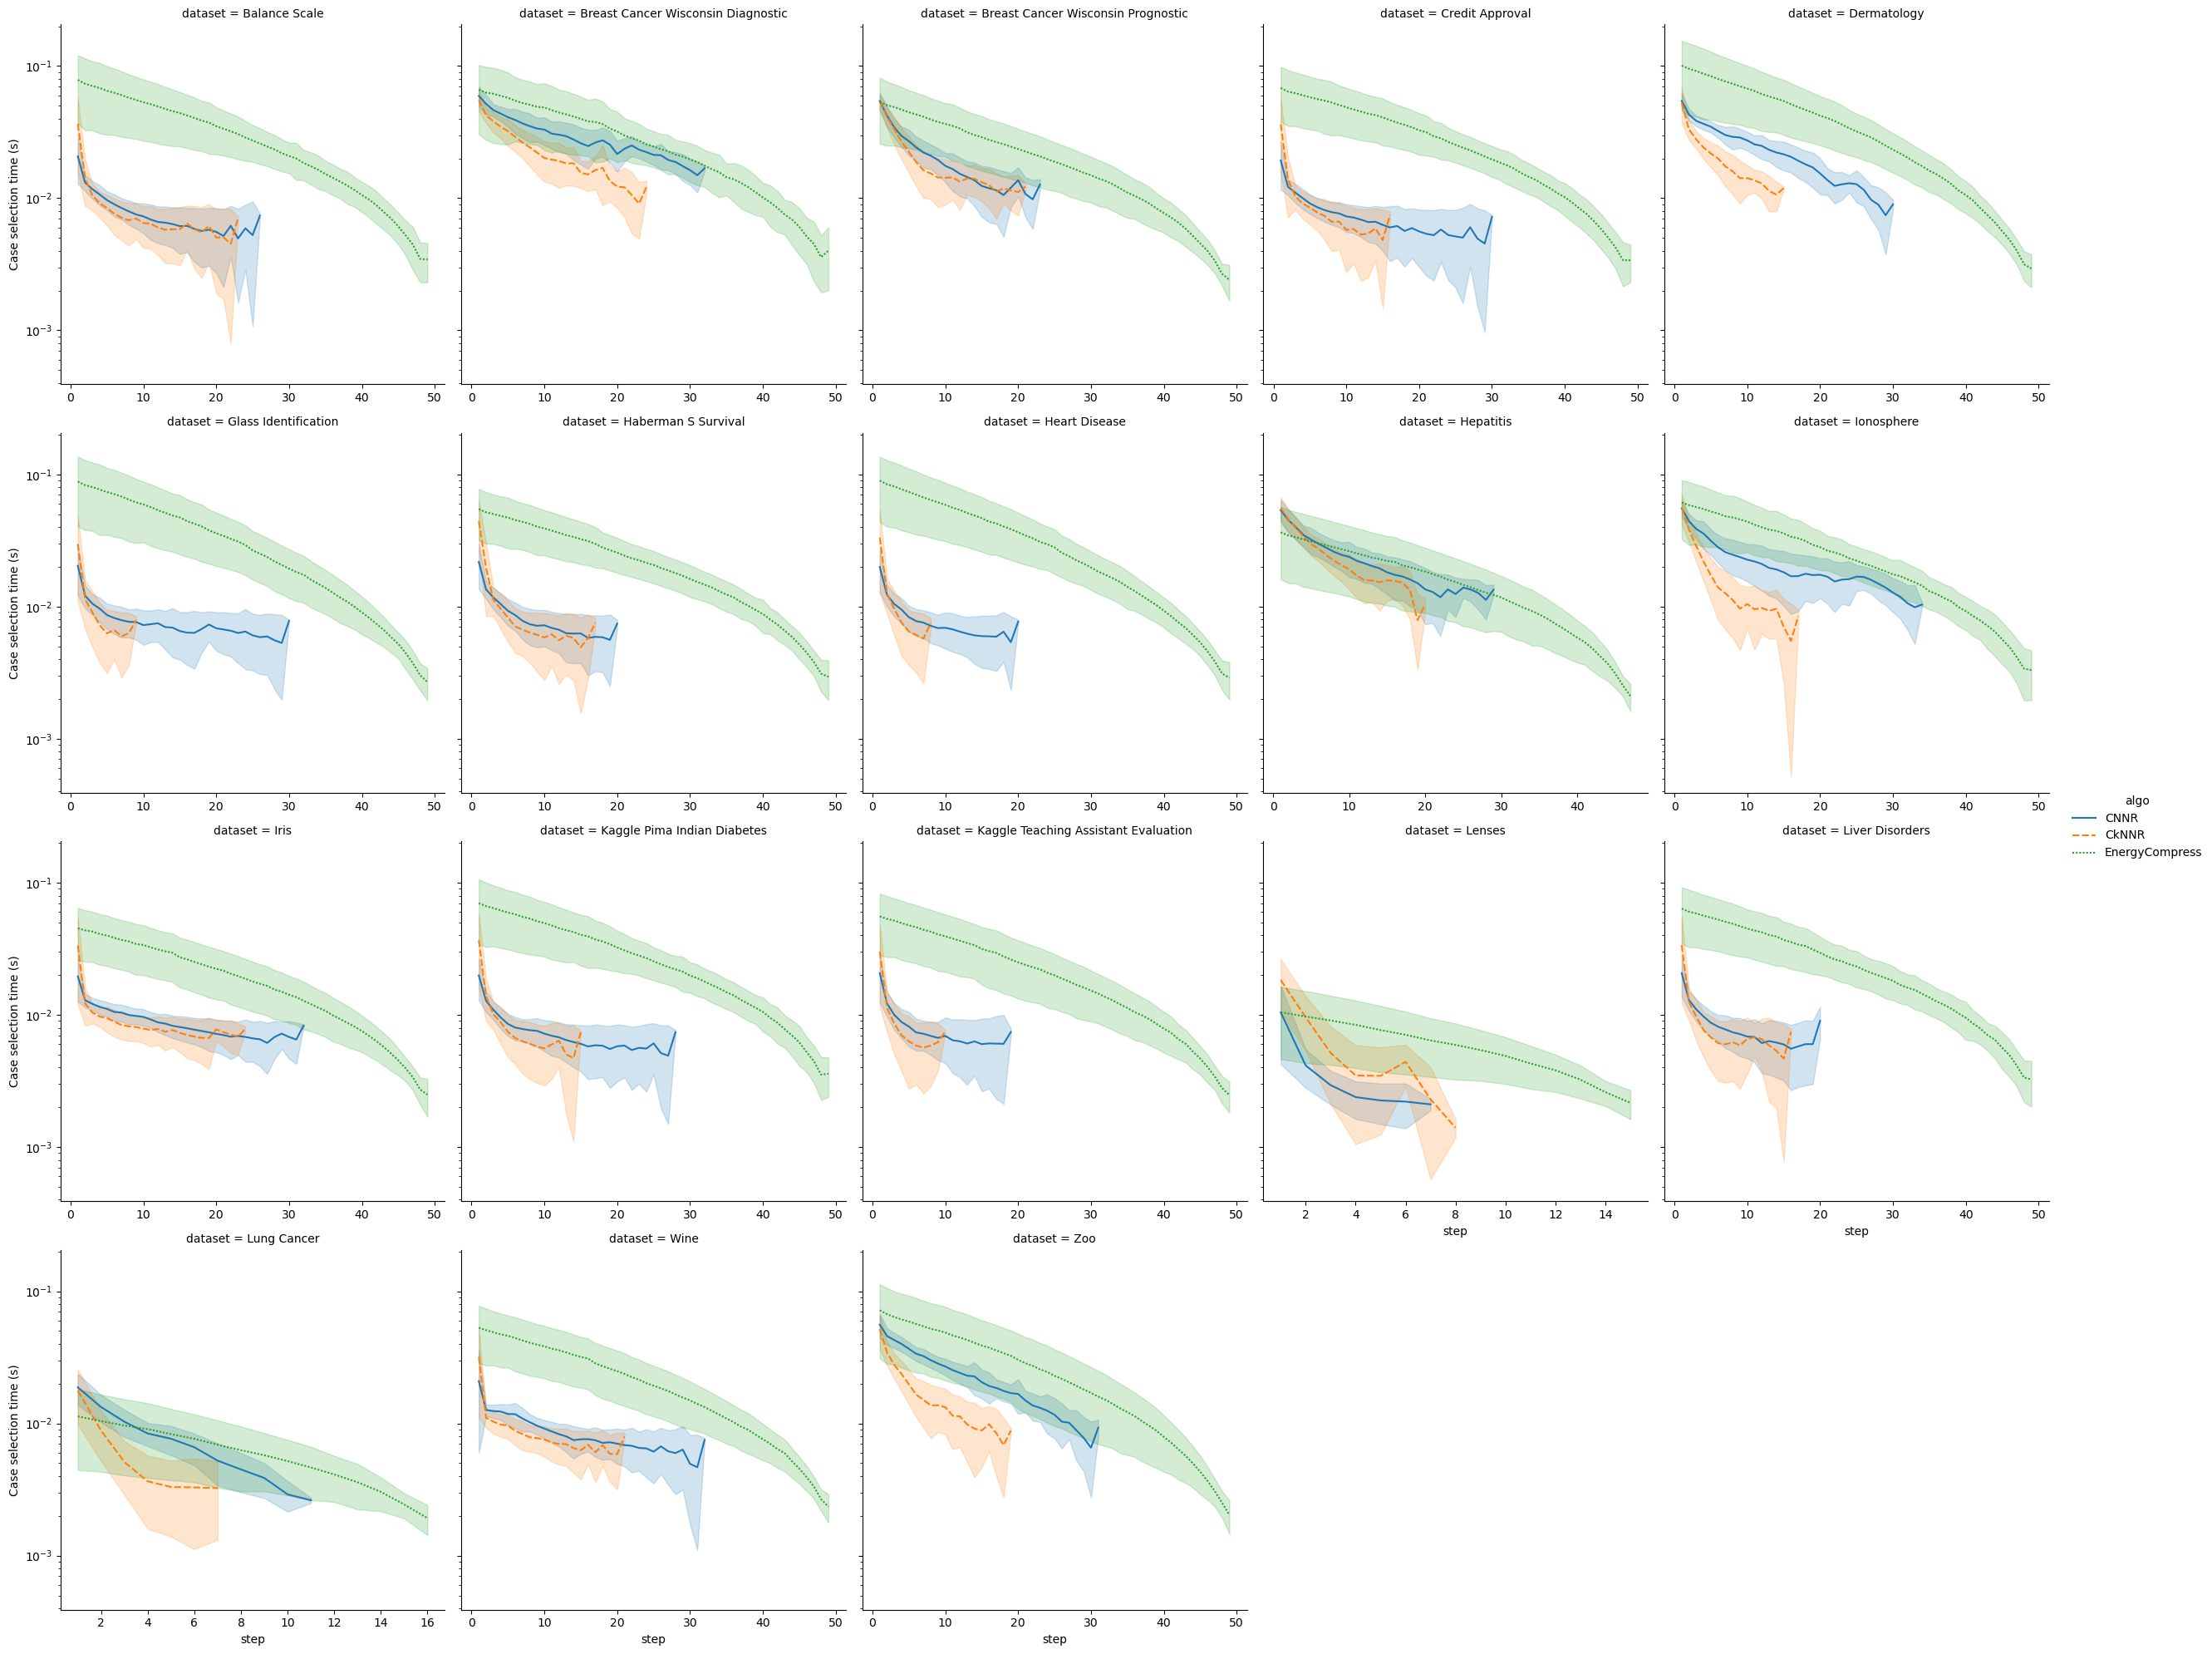

In [76]:
sns.relplot(
    precise_df_complete.reset_index(drop="fold"),
    x="step",
    y="fit_time",
    hue="algo", style="algo", 
    col="dataset", col_wrap = 5,
    kind="line", errorbar=('sd'), facet_kws={"sharex":False}).set(yscale = 'log', ylabel="Case selection time (s)")


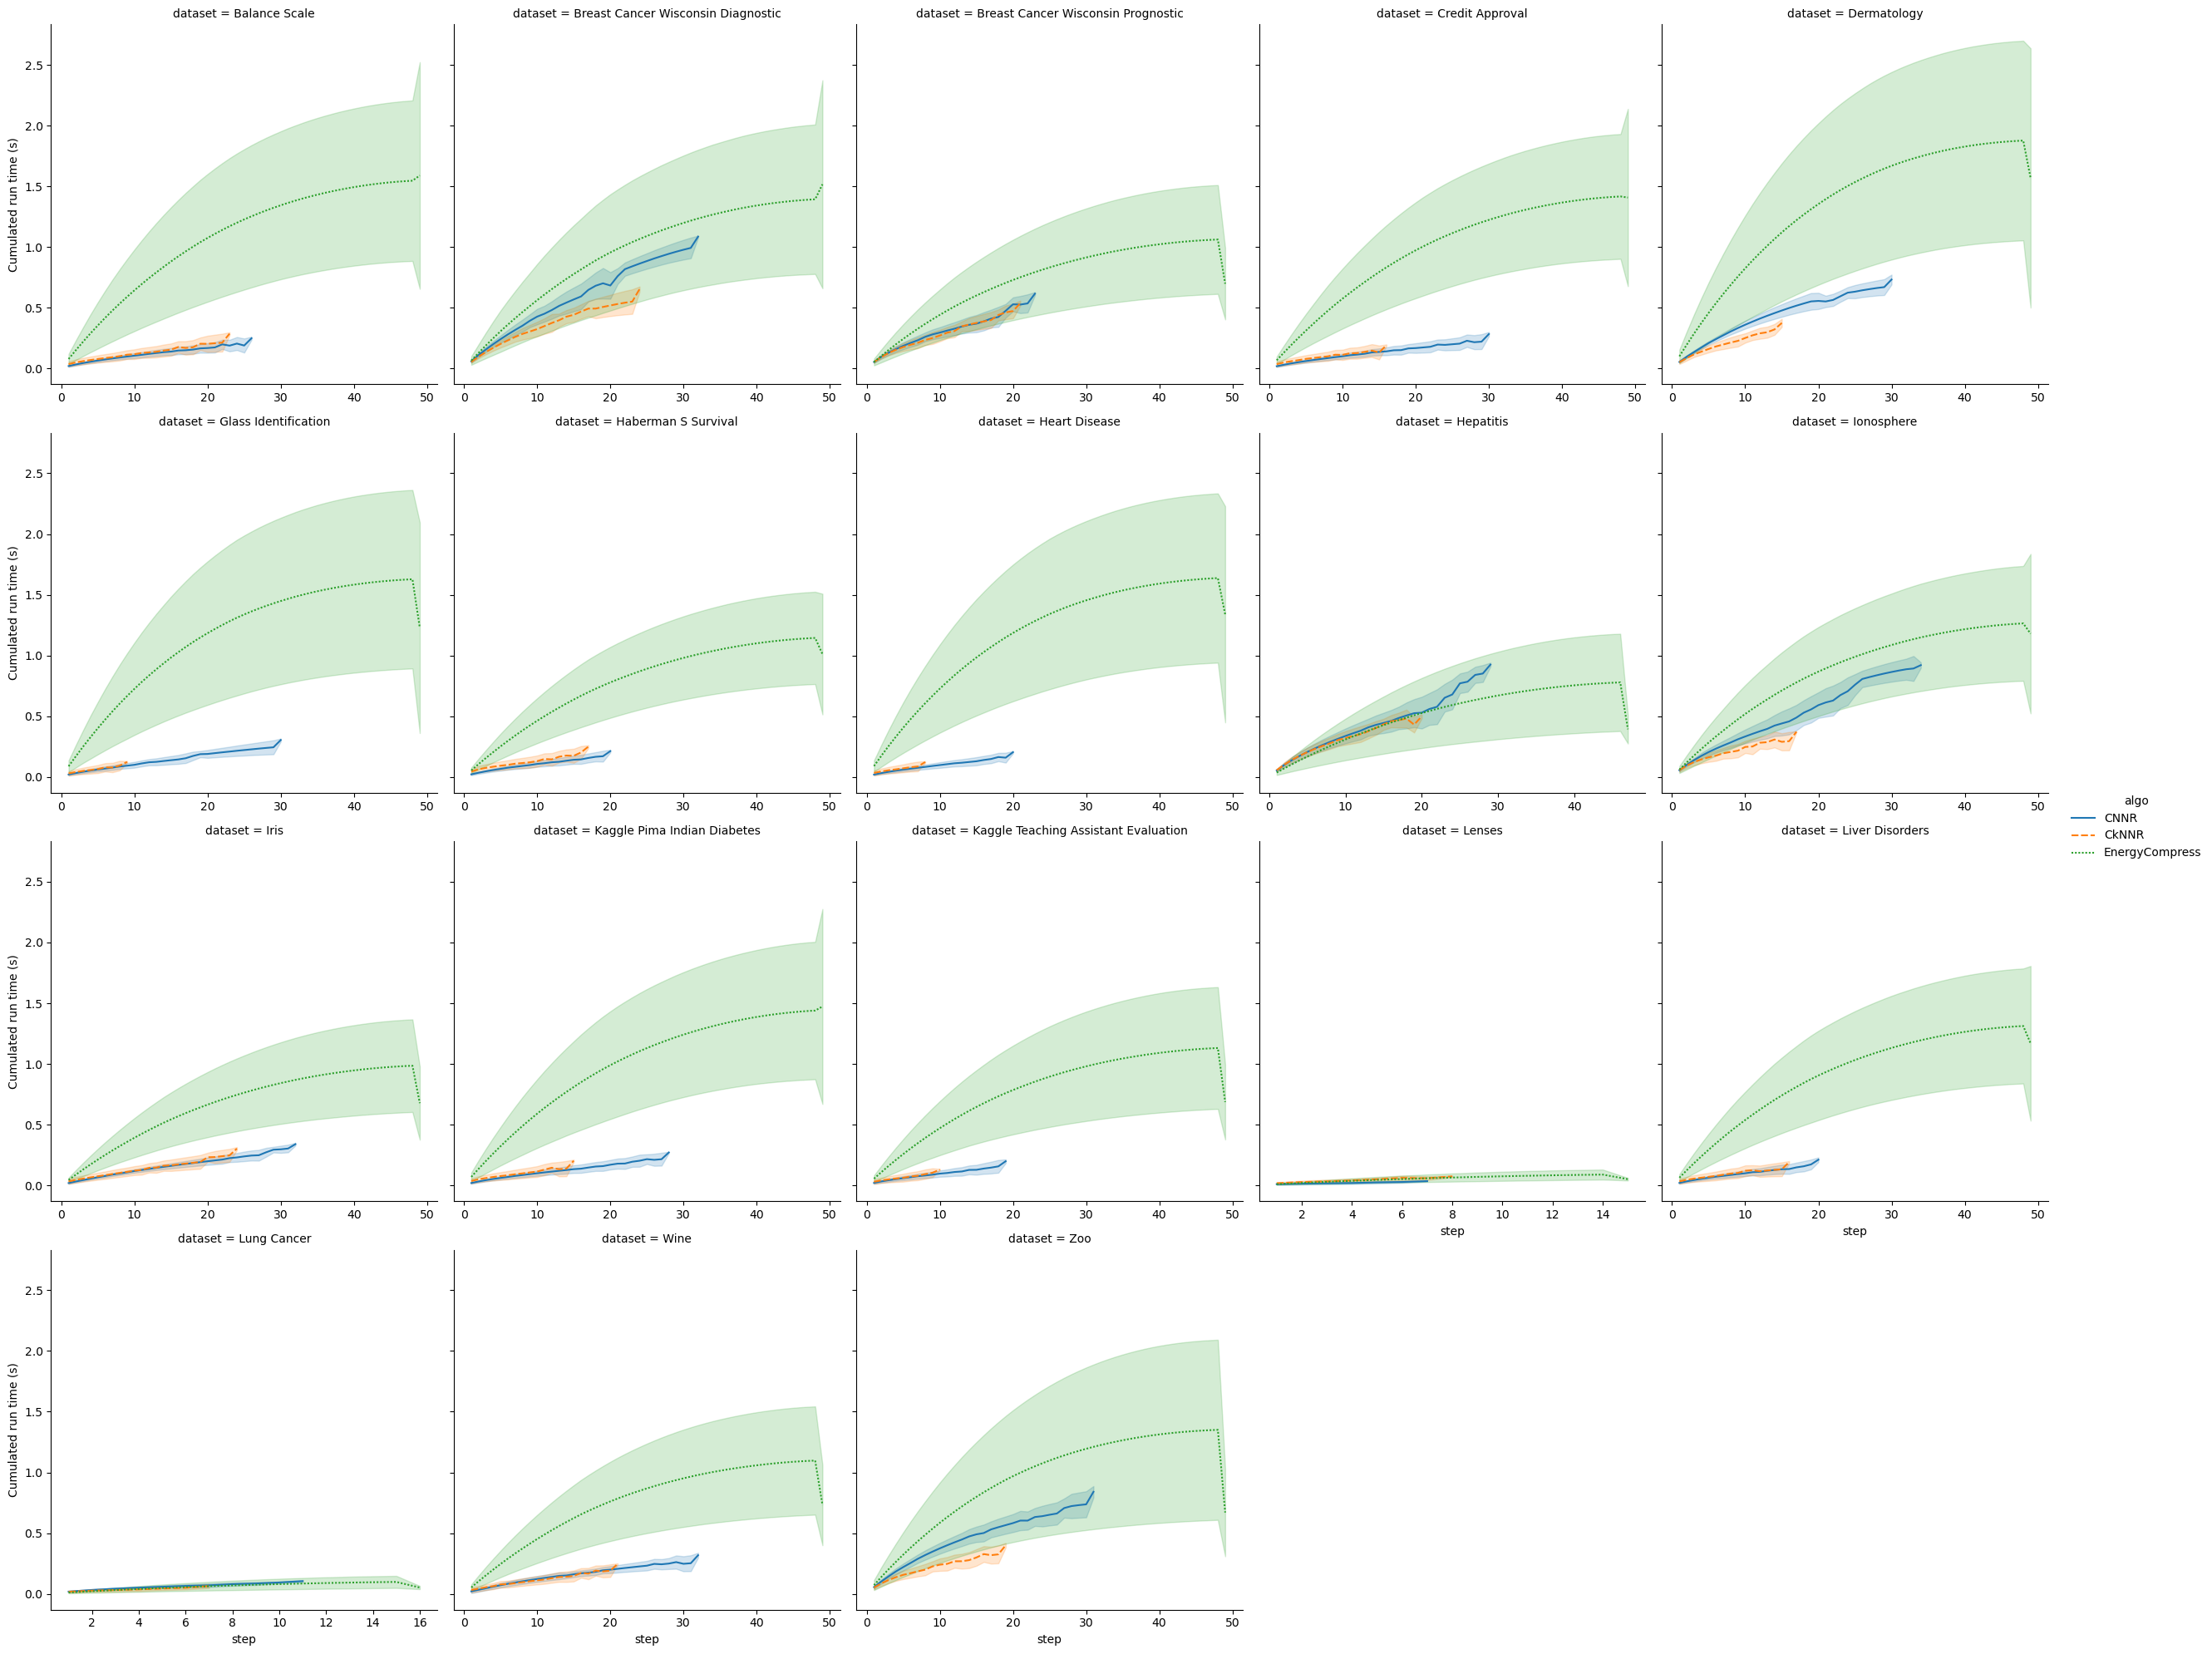

In [78]:
sns.relplot(
    precise_df_complete.reset_index(drop="fold"),
    x="step",
    y="cum_fit_time",
    hue="algo", style="algo", 
    col="dataset", col_wrap = 5,
    kind="line", errorbar=('sd'), facet_kws={"sharex":False}).set(ylabel="Cumulated run time (s)")

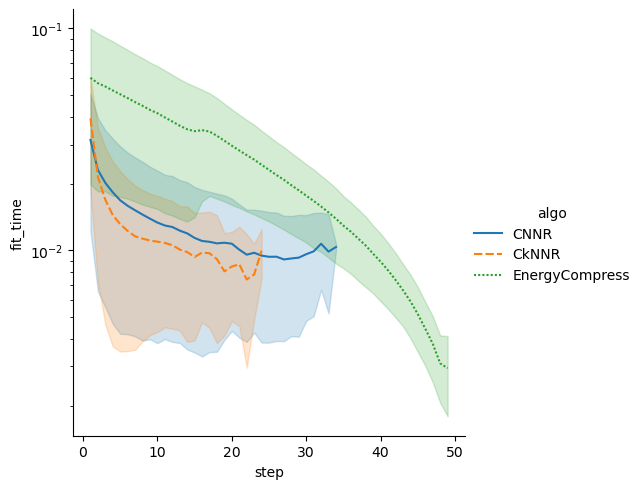

In [65]:
sns.relplot(
    precise_df_complete.reset_index(drop="fold"),
    x="step",
    y="fit_time",
    hue="algo", style="algo", 
    kind="line", errorbar=('sd'), facet_kws={"sharex":False}).set(yscale = 'log', ylabel="Case selection time (s)")

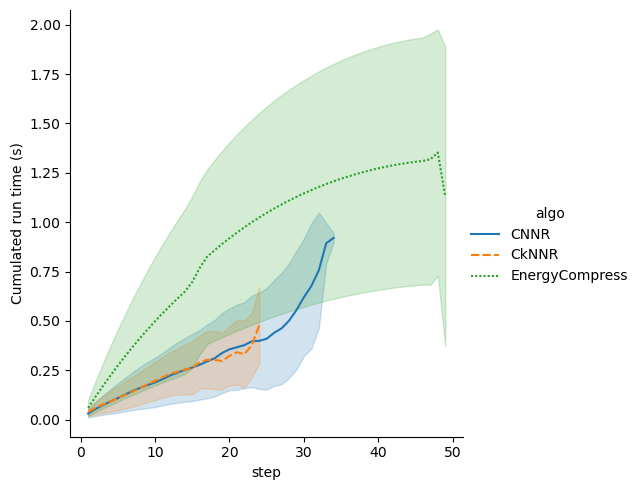

In [79]:
sns.relplot(
    precise_df_complete.reset_index(drop="fold"),
    x="step",
    y="cum_fit_time",
    hue="algo", style="algo", 
    kind="line", errorbar=('sd'), facet_kws={"sharex":False}).set(ylabel="Cumulated run time (s)")